<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            border-left: 5px solid #1f77b4; 
            padding: 20px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05); 
            max-width: 800px; 
            margin-bottom: 25px;">
    
<h1 style="color: #212529; margin-top: 0; margin-bottom: 5px; font-size: 26px; font-weight: 700;">
    Part II: CMS Open Data
</h1>
<br>
<p style="color: #6c757d; margin-top: 0; margin-bottom: 20px; font-size: 18px; font-weight: bold;">
    Notebook 7: Independent $Z$-Boson Reconstruction
</p>

<hr style="border: 0; border-top: 1px solid #dee2e6; margin-bottom: 15px;">

<table style="border-collapse: collapse; width: 100%; font-size: 14px; line-height: 1.6;">
    <tr>
        <td style="padding: 4px 0; width: 150px; font-weight: bold; color: #495057;">Author:</td>
        <td style="padding: 4px 0; color: #212529;">Uditangshu Roy</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Affiliation:</td>
        <td style="padding: 4px 0; color: #212529;">Undergraduate, Department of Physics and Astronomy, The University of Manchester</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Contact:</td>
        <td style="padding: 4px 0; color: #1f77b4; text-decoration: none;">roy.uditangshu@gmail.com</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Date:</td>
        <td style="padding: 4px 0; color: #212529;">August 2026</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Dataset Source:</td>
        <td style="padding: 4px 0; color: #212529;">CERN Open Data: <i> Datasets derived from the Run2011A SingleElectron, SingleMu, DoubleElectron, and DoubleMu primary datasets</i>.
            <code>Dimuon_DoubleMu.csv</code>. McCauley, T. Recorded 2011. Published 2017.</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Software Env.:</td>
        <td style="padding: 4px 0; color: #212529;">Python 3.11+, Pandas, Matplotlib, NumPy, Pathlib, SciPy, IPython</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">ORCID:</td>
        <td style="padding: 4px 0; color: #212529; font-family: monospace; letter-spacing: 0.5px;"><a href="https://orcid.org/0009-0005-7992-3549">0009-0005-7992-3549</a></td>
    </tr>
</table>
</div>

## 1. &nbsp; Introduction

The event selection performed in Notebook 6 produced a high-purity sample containing 5,233 Z-boson candidate events. The invariant mass is now reconstructed independently from the measured four-momentum components, allowing direct validation of the supplied dataset quantities and an experimental determination of the Z-boson mass.

In [1]:
#Import libraries and modules

import sys
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utilities import (
    make_formatter,
    dict_to_summary_df,
    multiple_dicts_to_summary_df
)

from src.particles import *

from src.validation import analyse_residuals

from src.plotting import (
    set_plot_style,
    histogram_peak,
    histogram_bin_centers,
    plot_overlay_histogram,
    plot_mass_fits,
    plot_scatter
)

from src.fourvectors import (
    invariant_mass_fourvector,
    invariant_mass_massless
)

from src.fit_peaks import(
    gaussian_peak,
    gaussian_fwhm,
    breit_wigner_peak,
    breit_wigner_fwhm,
    voigt_peak,
    voigt_fwhm,
    voigt_fwhm_error,
    initial_parameter_guess,
    popt_and_pcov,
    fit_statistics
)

set_plot_style()  # sets matplotlib rc-params

#Center-align outputs
display(HTML("""
<style>
.jp-OutputArea-output {
    display: flex;
    justify-content: center;
    align-items: center;
}
</style>
"""))

In [2]:
#Load Dataset
dimuon_selected = pd.read_csv("../../data/processed/z_dimuon_part_2_selected.csv")

## 2. &nbsp; Four-Momentum and Invariant Mass

### 2.1 &nbsp; Invariant Mass Derivation

The invariant mass reconstruction was derived in detail in Notebook 3 and is therefore not repeated here. In the present analysis, however, the reconstruction is performed using the measured four-momentum components provided in the full CMS dataset. For each selected event, the energies $E_1$ and $E_2$, together with the Cartesian momentum components $p_x$, $p_y$, and $p_z$ of both muons, are combined to obtain the invariant mass of the dimuon system. It follows the relation:

$$ M^2 = (E_1 + E_2)^2 - (p_{x1} + p_{x2})^2 - (p_{y1} + p_{y2})^2 - (p_{z1} + p_{z2})^2\:. \tag{1} $$

This approach differs from the reconstruction performed on the simplified dataset in Notebook 3, where the energy was calculated from the transverse momentum, pseudorapidity, and assumed muon rest mass. Here, the experimentally reconstructed energy values supplied by CMS are retained directly, allowing the invariant mass to be obtained from the complete measured four-vectors.

The resulting distribution therefore provides an independent reconstruction of the $Z \rightarrow \mu^+\mu^-$ resonance from the selected event sample, without using the precomputed invariant mass $M$ supplied in the dataset.

### 2.2 &nbsp; Exact Invariant Mass Reconstruction

In [3]:
inv_mass_exact = invariant_mass_fourvector(dimuon_selected)

peak_exact = histogram_peak(inv_mass_exact)

### 2.3 &nbsp; Massless Approximation

In [4]:
inv_mass_massless = invariant_mass_massless(dimuon_selected)

peak_massless = histogram_peak(inv_mass_massless)

### 2.4 &nbsp; Statistical Comparison of the Methods

In [5]:
mass_difference = inv_mass_exact - inv_mass_massless
absolute_difference = np.abs(mass_difference)

inv_mass_comparison = {
    "Mean Absolute Difference": absolute_difference.mean(),
    "Standard Deviation": mass_difference.std(),
    "Maximum Difference": absolute_difference.max(),
    "Minimum Difference": absolute_difference.min(),
    "Peak Difference": abs(peak_exact - peak_massless)
}

inv_mass_comparison_summary = dict_to_summary_df(
    inv_mass_comparison,
    value_col = "Value (GeV)",
    caption="<b>Table 1:</b> Statistical comparison between invariant mass reconstruction methods."
)

inv_mass_comparison_summary

Quantity,Value (GeV)
Mean Absolute Difference,0.0159
Standard Deviation,0.3971
Maximum Difference,22.7542
Minimum Difference,1.945e-07
Peak Difference,0.0849


### 2.5 &nbsp; Histogram Representation

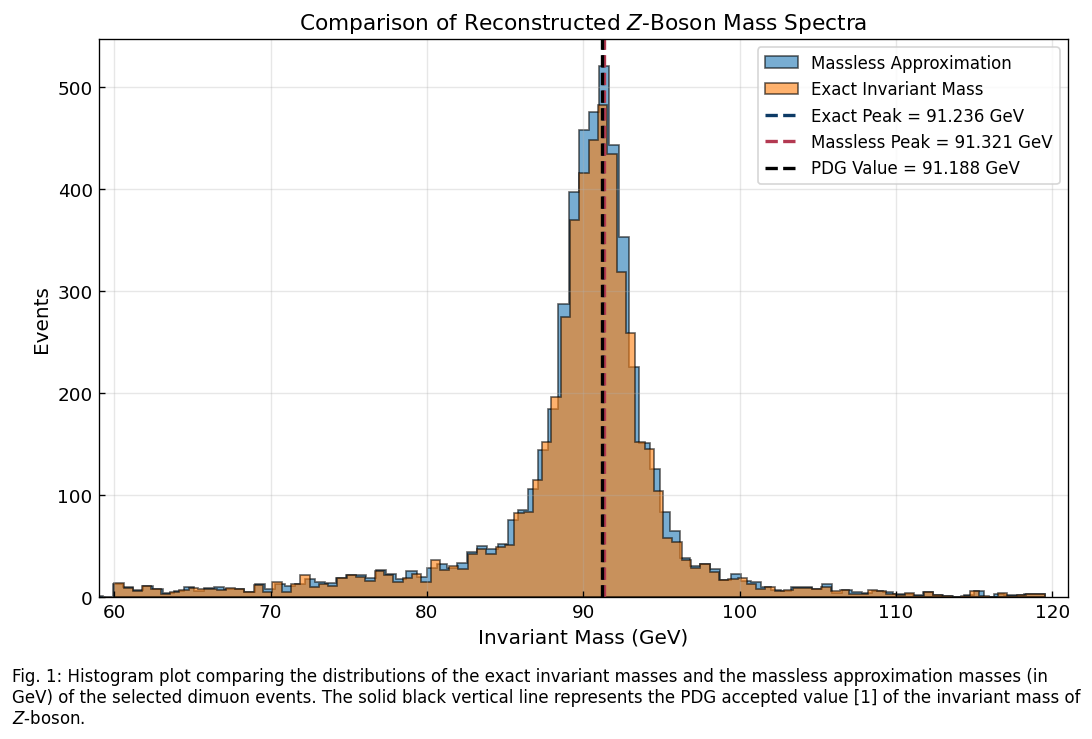

In [6]:
plot_overlay_histogram(
    inv_mass_massless,
    inv_mass_exact,
    bins=100,
    xlabel="Invariant Mass (GeV)",
    ylabel="Events",
    title=r"Comparison of Reconstructed $Z$-Boson Mass Spectra",
    colors=("#1f77b4", "#ff7f0e"),
    label1="Massless Approximation",
    label2="Exact Invariant Mass",
    vlines=[
        (peak_exact, f"Exact Peak = {peak_exact:.3f} GeV", "#0d3b66"),
        (peak_massless, f"Massless Peak = {peak_massless:.3f} GeV", "#b33951"),
        (PDG_Z_MASS, f"PDG Value = {PDG_Z_MASS:.3f} GeV", "black")    
    ],
    xlimit=(59, 121),  # Mass window used for filtering in the previous notebook
    caption="""Fig. 1: Histogram plot comparing the distributions of the exact invariant masses and the massless approximation masses (in GeV) of the selected dimuon events.\
 The solid black vertical line represents the PDG accepted value [1] of the invariant mass of $Z$-boson.""",
    save_path="../../figures/z_mumu_selected_mass_spectra_part_2.png",
    alt_caption=f"""Histogram plot comparing the distributions of the exact invariant masses and the massless approximation masses (in GeV) of the selected dimuon events.\
 The solid dashed dark blue and red lines represent the exact and the massless approximation invariant mass peaks respectively.\
 The solid black vertical line represents the PDG accepted value, {PDG_Z_MASS:.3f} GeV, of the invariant mass of $Z$-boson."""
)

The reconstructed invariant mass distributions obtained using the four-vector calculation and the massless approximation are effectively indistinguishable over the selected $60–120\,\text{GeV}$ mass range. The exact invariant mass distribution exhibits a clear $Z$-boson resonance centred at approximately $91.24\,\text{GeV}$, whereas the massless approximation has a peak at a slightly larger $91.32\,\text{GeV}$. The close agreement demonstrates that neglecting the muon rest mass introduces no significant change to the reconstructed $Z$-boson spectrum at the energies considered. However, compared to the same difference in the case of the simpler dataset in Part I of the project, the massless approximation is relatively less accurate for the larger dimuon sample. The reconstructed peak also lies close to the accepted PDG value of $91.188\,\text{GeV}$ [1], providing an initial indication that the independent reconstruction successfully reproduces the expected $Z$-boson resonance.

## 3. &nbsp; Peak Fitting

The position of the $Z$-boson resonance was initially estimated from the centre of the histogram bin containing the largest number of events. While this provides a simple estimate of the peak position, it is inherently dependent on the chosen bin width and does not provide an uncertainty on the measured resonance parameters. To obtain a more quantitative determination, the reconstructed invariant mass distribution is fitted using several models describing the shape of the resonance.

Three functional forms are considered: a <b>Gaussian distribution</b>, a <b>Breit–Wigner resonance profile</b>, and a <b>Voigt profile</b>. The Gaussian provides an empirical description of the observed peak and is useful for characterising the detector-smeared distribution. The Breit–Wigner function describes the intrinsic resonance associated with the finite lifetime of the $Z$-boson, while the Voigt profile combines a Breit–Wigner-type resonance with Gaussian broadening and therefore provides a more realistic description of a resonance observed experimentally. The models are fitted over a restricted region surrounding the $Z$-boson peak to minimise the influence of the non-resonant background and distant distribution tails.

### 3.1 &nbsp; Histogram Bin Centres for Fitting

The invariant mass distribution is first converted into a binned representation for the fitting procedure. For the $i$-th bin, the observed number of events is denoted by $N_i$, with the corresponding bin centre $M_i$ used as the independent variable in the fit. The fitting region is restricted to $80–100\,\text{GeV}$, which encompasses the reconstructed $Z$-boson resonance while limiting the contribution from the broader low- and high-mass tails of the distribution.

Since the number of events in each histogram bin represents a counting measurement, the statistical fluctuations in the bin contents are approximately Poisson distributed. For a Poisson distribution with an observed count $N_i$, the standard deviation is $\sqrt{N_i}$. The statistical uncertainty assigned to each bin is therefore taken as: $ \sigma_i = \sqrt{N_i}\,$. These uncertainties are used as weights during the least-squares fitting procedure, such that bins with larger statistical uncertainties contribute proportionally less to the fit. In the event that a bin contains zero events, $\sqrt{N_i}$ would give zero uncertainty and therefore an undefined statistical weight. To avoid this numerical issue, a minimum uncertainty corresponding to one event is imposed,

$$ \sigma_i = \sqrt{\max(N_i,\,1)} \:. \tag{1} $$

The resulting set of bin centres, event counts and statistical uncertainties forms the input to each of the resonance models considered below. The same binned data and uncertainties are used for the Gaussian, Breit–Wigner and Voigt fits to ensure that the models can be compared consistently.

In [7]:
bin_counts, bin_centres = histogram_bin_centers(inv_mass_exact, bins=200)

# Peak region
fit_mask = (
    (bin_centres >= 80) &
    (bin_centres <= 100)
)

x_fit = bin_centres[fit_mask]
y_fit = bin_counts[fit_mask]

y_error = np.sqrt(np.maximum(y_fit, 1))  # Sigma_i values

### 3.2 &nbsp; Gaussian Fitting

The first model used to describe the reconstructed $Z$-boson resonance is a Gaussian distribution with a linear background component. A Gaussian provides a simple empirical description of the approximately symmetric central region of the observed peak, while the background term accounts for the non-zero event yield underlying the resonance.

The fitted function is:

$$ A \exp\left[-\frac{(M-\mu)^2}{2\sigma^2}\right] + c_0 + c_1(M-\mu) \:. \tag{2} $$

Here, $M$ represents the invariant mass, $A$ is the amplitude of the Gaussian peak, $\mu$ is the fitted position of the resonance, and $\sigma$ is the Gaussian standard deviation and therefore characterises the width of the reconstructed peak. The parameters $c_0$ and $c_1$ describe the linear background, with $c_0$ representing its value at the fitted peak position and $c_1$ describing its slope.

The fitted value of $\mu$ provides an estimate of the reconstructed $Z$-boson mass, while the Gaussian full width at half maximum (FWHM) is related to the standard deviation by $ \text{FWHM} = 2\sqrt{2\ln 2}\,\sigma\approx 2.355\sigma \, $. Similarly, its uncertainty is related as $ \delta\,\text{FWHM} = 2\sqrt{2\ln 2} \,\delta \sigma $, where $\delta \sigma$ is the error on the standard deviation.

The Gaussian model is not intended to represent the intrinsic physical line shape of the $Z$-boson. Rather, it provides an empirical reference against which the more physically motivated Breit–Wigner and Voigt models can subsequently be compared. It is defined by the <code>gaussian_peak_fit</code> function in <code>fit_peaks.py</code>.

In [8]:
# Optional parameters and errors for Gaussian fit

p0_gaussian = list(initial_parameter_guess(x_fit, y_fit)["gaussian"].values())

gaussian_curve_fit_data = popt_and_pcov(
    gaussian_peak,
    x_fit,
    y_fit,
    y_error,
    initial_guess=p0_gaussian
)

### 3.3 &nbsp; Breit–Wigner Fit

While the Gaussian model provides a useful empirical description of the reconstructed resonance, the $Z$-boson is an unstable particle and therefore possesses a finite natural decay width. A more physically motivated description of an unstable resonance is provided by the Breit–Wigner distribution, which describes the characteristic line shape arising from the finite lifetime of a particle.

The Breit–Wigner model, $f(M)$, used here is combined with the same linear background employed for the Gaussian fit, and is mathematically descibed as:
$$ f(M) = A\frac{\gamma^2}{(M-\mu)^2+\gamma^2} + c_0 + c_1(M-\mu) \:. \tag{3} $$

Here, $A$ is the resonance amplitude, $\mu$ represents the fitted central position of the resonance, and $\gamma$ is the half-width parameter. The parameters $c_0$ and $c_1$ describe the linear background contribution as described before.

For this parameterisation, the full width at half maximum is directly related to $\gamma$ by $\text{FWHM}=2\gamma$. Similarly, its uncertainty is related as $ \delta \, \text{FWHM} = 2 \, \delta \gamma $, where $\delta \gamma$ is the error on the half-width parameter.

The fitted value of $\mu$ therefore provides an estimate of the reconstructed $Z$-boson mass, while the fitted width provides information about the observed breadth of the resonance. The Breit–Wigner model is expected to provide a more physically meaningful description of the intrinsic resonance shape than a purely Gaussian model. However, the experimentally reconstructed width also contains contributions from detector resolution, binning and the event-selection procedure, meaning that the fitted width should not be interpreted directly as a precision measurement of the intrinsic $Z$-boson decay width. It is defined by the <code>breit_wigner_peak_fit</code> function in <code>fit_peaks.py</code>.

In [9]:
# Optional parameters and errors for Breit-Wigner fit

p0_breit_wigner = list(initial_parameter_guess(x_fit, y_fit)["breit_wigner"].values())

breit_wigner_curve_fit_data = popt_and_pcov(
    breit_wigner_peak,
    x_fit,
    y_fit,
    y_error,
    initial_guess=p0_breit_wigner
)

### 3.4 &nbsp; Voigt Fit

The reconstructed invariant-mass peak is affected by both the intrinsic width of the (Z)-boson and the finite experimental resolution. The Breit–Wigner distribution describes the intrinsic resonance shape, while a Gaussian distribution provides a simple approximation to the detector-resolution contribution. Their combination is therefore described by a Voigt profile, which is the convolution of a Gaussian and a Lorentzian distribution.

The Voigt model used in the analysis is:

$$ f(M) = A\,V(M-\mu;\sigma,\gamma) + c_0 + c_1(M-\mu) \:, \tag{4} $$

where $V$ denotes the Voigt profile. The parameter $\mu$ specifies the central position of the resonance, $\sigma$ characterises the Gaussian resolution component, and $\gamma$ represents the Lorentzian half-width associated with the intrinsic resonance. The remaining parameters $A$, $c_0$ and $c_1$ describe the peak amplitude and linear background, as described before.

The Voigt profile does not possess a simple exact analytical expression for its FWHM. An accurate approximation is given by:

$$\text{FWHM}_{\text{Voigt}} \approx 0.5343f_{L} + \sqrt{0.2169 f_{L}^2 + f_{G}^2} \:, \tag{5} $$

where $f_L = 2 \gamma$ is the Lorentzian FWHM and $f_G = 2\sqrt{2\ln 2} \,\sigma$ is the Gaussian FWHM. The propagation for its uncertainty is a complicated and drawn-out process if done manually. Hence, we rely on numerical derivatives to compute the uncertainty. The uncertainty propagation, involving covariance, is of the form:

$$\sigma_W^2 = \left( \frac{\partial W}{\partial \sigma} \right)^2 \delta\sigma^2 + \left( \frac{\partial W}{\partial \gamma} \right)^2 \delta\gamma^2 + 2 \left( \frac{\partial W}{\partial \sigma} \right) \left( \frac{\partial W}{\partial \gamma} \right) \mathrm{Cov}(\sigma, \gamma) \:, \tag{6} $$

where $W = W(\sigma, \, \gamma)$ is the FWHM, which is a function of both $\sigma$ and $\gamma$. $\delta\sigma$ and $\delta\gamma$ represent the errors on $\sigma$ and $\gamma$ respectively.

The Voigt model therefore provides a useful intermediate description between the purely empirical Gaussian model and the intrinsic Breit–Wigner resonance. In particular, it allows the analysis to distinguish conceptually between the natural resonance width and the broadening introduced by finite experimental resolution. It is defined by the <code>voigt_peak_fit</code> function in <code>fit_peaks.py</code>.

In [10]:
# Optional parameters and errors for Voigt fit

p0_voigt = list(initial_parameter_guess(x_fit, y_fit)["voigt"].values())

voigt_curve_fit_data = popt_and_pcov(
    voigt_peak,
    x_fit,
    y_fit,
    y_error,
    initial_guess=p0_voigt
)

## 4. &nbsp; Goodness-of-Fit and Model Comparison

### 4.1 &nbsp; Parameter Estimation Using Weighted Least Squares

The parameters of each resonance model are determined using nonlinear least-squares fitting. The <code>curve_fit</code> method from <code>scipy.optimize</code> is used to determine the parameter values that provide the best agreement between the model prediction and the observed histogram counts.

For a set of measured bin contents $N_i$, model predictions $f(M_i)$, and statistical uncertainties $\sigma_i$, the fitting procedure minimises the weighted sum of squared residuals. The statistical uncertainties are taken from the Poisson counting uncertainty of each histogram bin, $\sigma_i = \sqrt{N_i}$, with the previously defined minimum uncertainty applied to empty bins. The fitting method also returns the covariance matrix of the fitted parameters. The uncertainty associated with an individual fitted parameter is obtained from the corresponding diagonal element, $\delta\theta_j = \sqrt{C_{jj}}$, where $C$ is the covariance matrix and $\theta_j$ denotes the $j$-th fitted parameter. The same fitting range, histogram and statistical uncertainties are used for all three resonance models. This ensures that differences between the fitted results arise from the models themselves rather than from different fitting conditions.


### 4.2 &nbsp; Chi-Squared Goodness of Fit Analysis

Once the best-fit parameters have been obtained, the agreement between each fitted model and the observed data is quantified using the chi-squared statistic,

$$ \sum_i \left( \frac{N_i - f(M_i)}{\sigma_i} \right)^2 \:. \tag{7} $$

Here, $N_i$ is the observed number of events in the $i$-th bin, $f(M_i)$ is the corresponding fitted prediction, and $\sigma_i$ is the statistical uncertainty of the observed bin content. The number of degrees of freedom is given by $\nu=n-k$, where $n$ is the number of fitted histogram bins and $k$ is the number of free parameters in the model. The reduced chi-squared statistic is therefore $
\chi^2_\nu = \frac{\chi^2}{\nu}$.

A reduced chi-squared value close to unity indicates that the deviations between the fitted model and the observed data are broadly consistent with the assumed statistical uncertainties. Values substantially greater than unity indicate poorer agreement, whereas values substantially below unity may indicate that the uncertainties are overestimated or that the model is particularly flexible.

The chi-squared statistic is also used to obtain a goodness-of-fit $p$-value. For a model with $\nu$ degrees of freedom,

$$p = P\left(\chi^2_{\nu} \geq \chi^2_{\mathrm{obs}}\right) = 1 - F_{\chi^2}\left(\chi^2_{\mathrm{obs}}; \nu\right) \:, \tag{8}$$

where $F_{\chi^2}$ is the cumulative distribution function of the chi-squared distribution.

The $p$-value represents the probability of obtaining a chi-squared value at least as large as the observed value if the fitted model provides an adequate description of the data. A small $p$-value therefore indicates tension between the model and the observed distribution, while a larger value indicates that the observed deviations are compatible with statistical fluctuations under the fitted model. The $p$-value should not be interpreted as the probability that the model itself is correct.


### 4.3 &nbsp; Akaike and Bayesian Information Criteria (AIC and BIC Comparison)

In addition to the chi-squared statistics, the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) are used to compare the relative quality of the Gaussian, Breit–Wigner and Voigt models. These criteria are particularly useful because they account for both the quality of the fit and the number of free parameters in the model.

For the present least-squares fits, the Akaike Information Criterion is calculated as $\chi^2+2k$, where $k$ is the number of fitted parameters. The second term penalises models containing additional parameters, preventing a more complicated model from being automatically favoured simply because it has greater flexibility.

The Bayesian Information Criterion is defined as $\chi^2+k\ln(n)$, where $k$ is the number of free parameters and $n$ is the number of fitted data points. The BIC therefore applies a stronger penalty to additional parameters than the AIC when the number of data points is large.

Both AIC and BIC are comparative rather than absolute measures. Their absolute values have little meaning in isolation; instead, the difference between models is considered. For either criterion, the model with the lower value is preferred. A substantially lower AIC or BIC therefore indicates that a model provides a better balance between agreement with the observed data and model complexity.

Together, the $\chi^2$, reduced $\chi^2$, $p$-value, AIC and BIC provide complementary measures of fit quality. The chi-squared statistics assess the agreement between the model and data relative to the assumed uncertainties, while AIC and BIC additionally penalise unnecessary model complexity. These measures are therefore used alongside the fitted peak position and width when comparing the three resonance models.

### 4.4 &nbsp; Model Fit Statistics Comparison

In [11]:
# FWHM Values added to the combined dictionaries

fit_formatter = make_formatter(decimals=3)  # Formatting instance

gaussian_fit_statistics = fit_statistics(
    gaussian_peak,
    x_fit,
    y_fit,
    y_error,
    gaussian_curve_fit_data[0]
)

gaussian_popt = gaussian_curve_fit_data[0]
gaussian_pcov = gaussian_curve_fit_data[1]

gaussian_sigma = gaussian_popt[2]
gaussian_sigma_error = np.sqrt(gaussian_pcov[2, 2])

gaussian_fwhm_val, gaussian_fwhm_err = gaussian_fwhm(gaussian_sigma, gaussian_sigma_error)
gaussian_fit_statistics["FWHM (GeV)"] = f"{fit_formatter(gaussian_fwhm_val)} ± {fit_formatter(gaussian_fwhm_err)}"
gaussian_fit_statistics["Relative Width"] = fit_formatter(gaussian_fwhm_val / PDG_Z_MASS)

                                   
breit_wigner_fit_statistics = fit_statistics(
    breit_wigner_peak,
    x_fit,
    y_fit,
    y_error,
    breit_wigner_curve_fit_data[0]
)

breit_wigner_popt = breit_wigner_curve_fit_data[0]
breit_wigner_pcov = breit_wigner_curve_fit_data[1]

breit_wigner_gamma = breit_wigner_popt[2]
breit_wigner_gamma_error = np.sqrt(breit_wigner_pcov[2, 2])

breit_wigner_fwhm_val, breit_wigner_fwhm_err = breit_wigner_fwhm(breit_wigner_gamma, breit_wigner_gamma_error)
breit_wigner_fit_statistics["FWHM (GeV)"] = f"{fit_formatter(breit_wigner_fwhm_val)} ± {fit_formatter(breit_wigner_fwhm_err)}"
breit_wigner_fit_statistics["Relative Width"] = fit_formatter(breit_wigner_fwhm_val / PDG_Z_MASS)


voigt_fit_statistics = fit_statistics(
    voigt_peak,
    x_fit,
    y_fit,
    y_error,
    voigt_curve_fit_data[0]
)

voigt_popt = voigt_curve_fit_data[0]
voigt_pcov = voigt_curve_fit_data[1]

voigt_sigma = voigt_popt[2]
voigt_gamma = voigt_popt[3]

voigt_fit_statistics["FWHM (GeV)"] = f"{fit_formatter(voigt_fwhm(voigt_sigma, voigt_gamma))} ± {fit_formatter(voigt_fwhm_error(voigt_sigma, voigt_gamma, voigt_pcov))}"
voigt_fit_statistics["Relative Width"] = fit_formatter(voigt_fwhm(voigt_sigma, voigt_gamma) / PDG_Z_MASS)

# Display comparison summary
comparison_table_row_keys = [
    "FWHM (GeV)",
    "Relative Width",
    "Chi-squared",
    "Degrees of Freedom",
    "Reduced Chi-squared",
    "p-value",
    "AIC",
    "BIC"
]

model_comparisons = multiple_dicts_to_summary_df(
    data_dicts={
        "Gaussian": gaussian_fit_statistics,
        "Breit-Wigner": breit_wigner_fit_statistics,
        "Voigt": voigt_fit_statistics
    },
    metric_col="Metric",
    keys_list=comparison_table_row_keys,
    caption=r"<b>Table 2:</b> Comparison Table of the Models for $Z$-boson"
)           

display(model_comparisons)

model_comparisons.data.to_csv(
    "../../data/processed/z_dimuon_part_2_fit_summary.csv",
    index=False
)  # Save the statistics

Metric,Gaussian,Breit-Wigner,Voigt
FWHM (GeV),4.883 ± 0.088,4.128 ± 0.134,4.419 ± 0.148
Relative Width,0.054,0.045,0.048
Chi-squared,116.3,75.15,65.39
Degrees of Freedom,62,62,61
Reduced Chi-squared,1.88,1.21,1.07
p-value,3.6e-05,0.12,0.33
AIC,126.3,85.15,77.39
BIC,137.32,96.18,90.61


The Gaussian model produces a chi-squared value of $116.30$ for $62$ degrees of freedom, corresponding to a reduced chi-squared of approximately $1.88$. Its goodness-of-fit $p$-value is $3.63\times10^{-5}$, or approximately $0.0036\%$. This very small $p$-value provides strong evidence against the Gaussian model as an adequate description of the observed invariant-mass distribution. Although the Gaussian captures the overall location and approximate shape of the resonance, the magnitude of the residual deviations is substantially larger than would be expected from statistical fluctuations alone. This indicates that the detailed shape of the reconstructed $Z$-boson peak is not well represented by a purely Gaussian profile.

The Breit–Wigner model provides a substantial improvement. Its chi-squared decreases to $75.15$ for $62$ degrees of freedom, giving a reduced chi-squared of $1.21$. The corresponding $p$-value is approximately $0.122$, meaning that there is no strong statistical evidence to reject the Breit–Wigner model at the conventional $5\%$ significance level. The improvement relative to the Gaussian model indicates that the resonance shape contains features that are better represented by the Lorentzian component of a Breit–Wigner distribution. In particular, the finite natural width of the unstable $Z$-boson produces a resonance shape that is not perfectly Gaussian.

The Voigt model provides the best overall fit of the three models considered. It gives a chi-squared value of $65.39$ for $61$ degrees of freedom and a reduced chi-squared of approximately $1.07$, which is close to unity. Its $p$-value of approximately $0.327$ indicates that the observed deviations between the model and data are compatible with statistical fluctuations under the fitted model. The Voigt profile therefore provides a statistically satisfactory description of the reconstructed resonance.

The improvement of the Voigt model over the Breit–Wigner model is particularly significant because the Voigt profile contains one additional free parameter. The additional Gaussian width parameter allows the model to account for broadening associated with experimental resolution while retaining the Lorentzian component associated with the intrinsic resonance width. Despite this additional parameter, the Voigt model is strongly favoured by both information criteria. Its AIC value of $77.39$ is lower than the Breit–Wigner value of $85.15$ and the Gaussian value of $126.30$. Similarly, its BIC value of $90.61$ is lower than $96.18$ for the Breit–Wigner model and $137.32$ for the Gaussian model. Since both AIC and BIC penalise models for additional free parameters, the lower values for the Voigt model indicate that its improvement in describing the data is sufficiently large to justify the additional parameter.

The relative widths of each model is measured as $\text{FWHM}\,/\,M_Z$, to produce a comparison with the same obtained from the subsequent $J/\psi$-meson study.

Overall, the fit statistics demonstrate a clear progression in the quality of the resonance description. The Gaussian model provides the poorest fit, with a strongly disfavoured goodness-of-fit $p$-value and the largest AIC and BIC values. The Breit–Wigner model provides a substantial improvement and gives an acceptable goodness of fit, while the Voigt model provides the closest agreement with the observed invariant-mass distribution. The reduced chi-squared value of approximately $1.07$, together with the largest $p$-value and smallest AIC and BIC values, identifies the Voigt profile as the preferred model among those considered. This is also physically reasonable, since the reconstructed resonance is expected to contain both intrinsic resonance broadening and additional smearing associated with the experimental measurement.

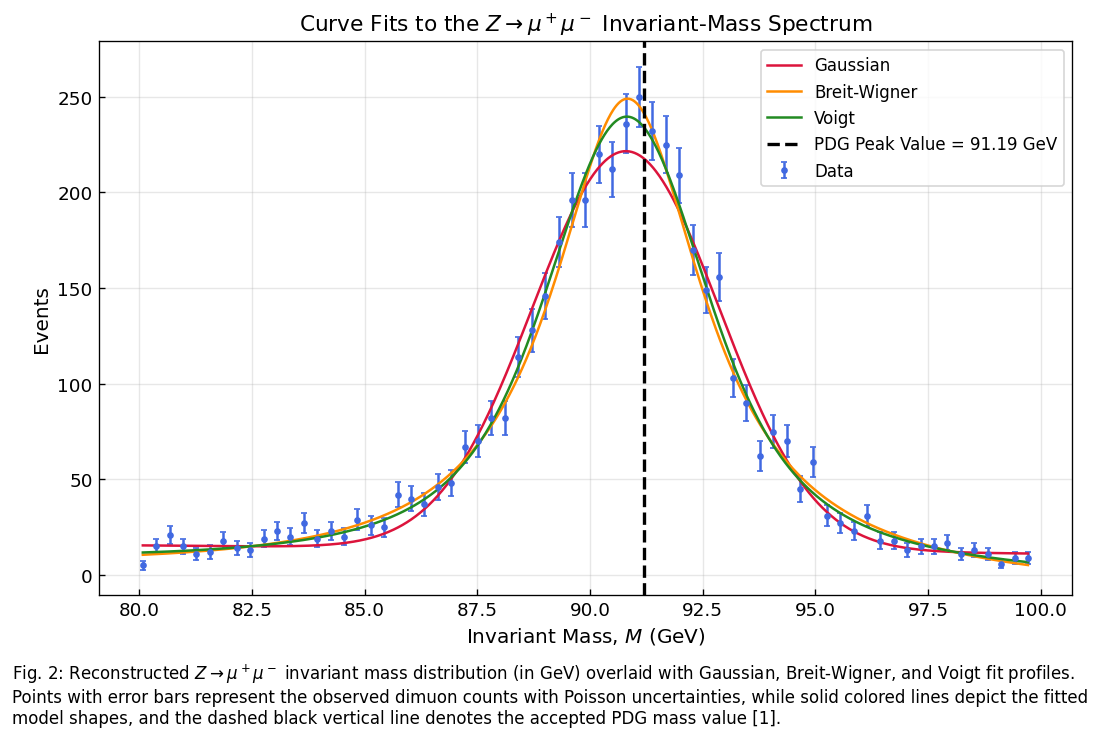

Figure saved at: ../../figures/z_mumu_mass_spectrum_curve_fits_part_2.png


In [12]:
x_plot = np.linspace(
    x_fit.min(),
    x_fit.max(),
    1000
)

gaussian_curve = gaussian_peak(
    x_plot,
    *gaussian_curve_fit_data[0]
)

breit_wigner_curve = breit_wigner_peak(
    x_plot,
    *breit_wigner_curve_fit_data[0]
)

voigt_curve = voigt_peak(
    x_plot,
    *voigt_curve_fit_data[0]
)

fit_curves = {
    "Gaussian": (gaussian_curve, "#DC143C"),
    "Breit-Wigner": (breit_wigner_curve, "#FF8C00"),
    "Voigt": (voigt_curve, "#228B22")
}

plot_mass_fits(
    x_fit,
    y_fit,
    y_error,
    fit_curves,
    x_plot=x_plot,
    xlabel=r"Invariant Mass, $M$ (GeV)",
    title=r"Curve Fits to the $ Z \rightarrow \mu^+ \mu^- $ Invariant-Mass Spectrum",
    vlines=[
        (PDG_Z_MASS, f"PDG Peak Value = {PDG_Z_MASS:.2f} GeV", "k")    
    ],
    caption="""Fig. 2: Reconstructed $Z \\rightarrow \\mu^+\\mu^-$ invariant mass distribution (in GeV) overlaid with Gaussian, Breit-Wigner, and Voigt fit profiles.\
 Points with error bars represent the observed dimuon counts with Poisson uncertainties, while solid colored lines depict the fitted model shapes, \
and the dashed black vertical line denotes the accepted PDG mass value [1].""",
    save_path="../../figures/z_mumu_mass_spectrum_curve_fits_part_2.png",
    alt_caption=f"""Reconstructed $Z \\rightarrow \\mu^+\\mu^-$ invariant mass distribution (in GeV) overlaid with Gaussian, Breit-Wigner, and Voigt fit profiles.\
 Points with error bars represent the observed dimuon counts with Poisson uncertainties, while solid colored lines depict the fitted model shapes, \
and the dashed black vertical line denotes the accepted PDG mass value of {PDG_Z_MASS:.2f} GeV."""
)

The fitted models are overlaid on the reconstructed invariant-mass distribution to provide a visual comparison of their descriptions of the $Z$-boson resonance. The Gaussian profile captures the general location of the peak but shows visible deviations from the data, consistent with its comparatively large reduced $\chi^2$ and very small $p$-value. The Breit–Wigner profile provides a closer description of the resonance and its tails, while the Voigt profile gives the closest overall agreement with the observed distribution. Additionally, the fitted peaks for all three models are situated slightly to the left of the reference marker, remaining marginally lower than the accepted PDG value. This visual behaviour is consistent with the quantitative fit statistics, which identify the Voigt model as the preferred description among the three models considered.

### 4.5 &nbsp; Residuals

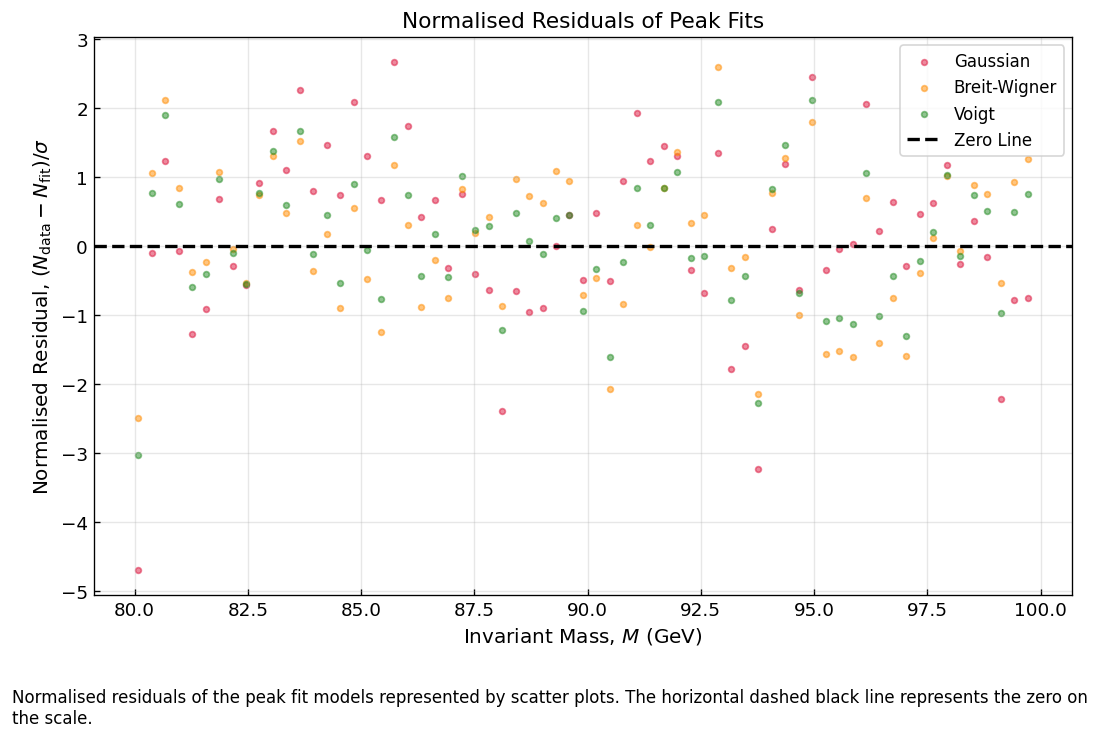

Figure saved at: figures/../../figures/z_mumu_peak_fit_normalised_residuals_part_2.png




Metric,Gaussian,Breit-Wigner,Voigt
Mean,0.169,0.085,0.093
Standard Deviation,1.307,1.056,0.983
Maximum Absolute Difference,4.690,2.594,3.032


In [13]:
gaussian_residuals = y_fit - gaussian_peak(x_fit, *gaussian_curve_fit_data[0])

breit_wigner_residuals = y_fit - breit_wigner_peak(x_fit, *breit_wigner_curve_fit_data[0])

voigt_residuals = y_fit - voigt_peak(x_fit, *voigt_curve_fit_data[0])

# Normalised residuals

gaussian_normalised_residuals = gaussian_residuals / y_error

breit_wigner_normalised_residuals = breit_wigner_residuals / y_error

voigt_normalised_residuals = voigt_residuals / y_error

plot_scatter(
    x_fit,
    [
        (gaussian_normalised_residuals, "Gaussian", "#DC143C"),
        (breit_wigner_normalised_residuals, "Breit-Wigner", "#FF8C00"),
        (voigt_normalised_residuals, "Voigt", "#228B22")
    ],
    hlines = [(0, "Zero Line", "black")],
    xlabel = r"Invariant Mass, $M$ (GeV)",
    ylabel = r"Normalised Residual, $(N_{\text{data}}-N_{\text{fit}})/\sigma$",
    title = "Normalised Residuals of Peak Fits",
    caption = "Fig. 3: Normalised residuals of the peak fit models represented by scatter plots.",
    save_path="../../figures/z_mumu_peak_fit_normalised_residuals_part_2.png",
    alt_caption="Normalised residuals of the peak fit models represented by scatter plots. The horizontal dashed black line represents the zero on the scale."
)


# The extreme difference limits are not required for the analysis presented here.

gaussian_residual_stats = analyse_residuals(gaussian_normalised_residuals)
breit_wigner_residual_stats = analyse_residuals(breit_wigner_normalised_residuals)
voigt_residual_stats = analyse_residuals(voigt_normalised_residuals)

residual_comparison_keys = ["Mean", "Standard Deviation", "Maximum Absolute Difference"]

print("\n")  # Blank lines for spacing

display(
    multiple_dicts_to_summary_df(
        data_dicts={
            "Gaussian": gaussian_residual_stats,
            "Breit-Wigner": breit_wigner_residual_stats,
            "Voigt": voigt_residual_stats
        },
        metric_col="Metric",
        keys_list=residual_comparison_keys,
        caption="<b>Table 3:</b> Residual Statistics for Peak-Fit Models",
        format_function=make_formatter(
            decimals=3,
            small_number_precision=1
        )
    )
)

print()  # Blank line for spacing

The residual analysis provides an additional assessment of how closely each fitted model reproduces the observed invariant-mass distribution. The residuals are calculated relative to the statistical uncertainty of each histogram bin, allowing deviations between the data and fitted models to be assessed on a common scale. A well-performing model is expected to produce residuals that fluctuate approximately randomly around zero, with a characteristic spread close to unity when expressed in units of the statistical uncertainty.

The Gaussian model exhibits the largest overall residual spread and the largest deviations from the measured distribution. This indicates that the discrepancies between the Gaussian profile and the data are not limited to isolated statistical fluctuations, but instead reflect a systematic mismatch between the assumed Gaussian shape and the observed resonance. This is consistent with the poor goodness-of-fit obtained previously.

The Breit–Wigner model produces a substantially narrower residual distribution, indicating a closer correspondence with the observed resonance shape. Its residuals are also centred close to zero, suggesting that the model does not exhibit a strong overall bias in either direction.

The Voigt model produces the residual distribution closest to the expected behaviour for a satisfactory fit, with the residuals concentrated around zero and a spread close to one statistical standard deviation. Although individual deviations remain, these are consistent with the finite statistical precision of the analysis rather than indicating a strong systematic mismatch. It also exhibits a standard deviation value closest to $1$ amongst the three models. The residual behaviour therefore provides independent support for the Voigt model as the preferred description of the reconstructed $Z$-boson resonance.

Overall, the residual analysis is consistent with the conclusions from the goodness-of-fit statistics: the Gaussian model provides the weakest description, the Breit–Wigner model gives a substantial improvement, and the Voigt profile provides the most satisfactory overall representation of the measured resonance.

## 5. &nbsp; Conclusion

This notebook presented the final reconstruction and detailed analysis of the $Z \rightarrow \mu^+\mu^-$ resonance using the simplified CMS Open Data sample. After applying the kinematic and invariant-mass selections, the selected events produced a clear resonance centred close to the expected $Z$-boson mass, demonstrating that the invariant-mass reconstruction successfully identifies the underlying physical signal.

The reconstructed resonance was subsequently investigated using Gaussian, Breit–Wigner and Voigt peak models. The Gaussian model provided relatively the poorest description of the observed distribution, while the Breit–Wigner model gave a substantial improvement. The Voigt profile provided the most satisfactory description among the models considered, with a reduced $\chi^2$ close to unity, an acceptable goodness-of-fit $p$-value, and the lowest AIC and BIC values. The residual analysis independently supported this conclusion, showing that the Voigt model produced the closest agreement between the fitted profile and the observed distribution.

The fitted peak position and width provide a more quantitative characterisation of the reconstructed resonance than the histogram peak alone. The results demonstrate that the observed $Z$-boson signal is consistent with the expected resonance while also illustrating the effects of detector resolution and the finite natural width of the $Z$-boson. Although the simplified nature of the dataset limits the precision of the reconstruction compared with a full CMS analysis, the agreement obtained demonstrates that the essential physics of resonance reconstruction can be recovered from the open data sample.

Overall, the analysis establishes a complete reconstruction and characterisation of the $Z \rightarrow \mu^+\mu^-$ resonance, from event selection and independent kinematic validation through to peak fitting, statistical model comparison and final resonance measurements.

## References

[1] <https://pdg.lbl.gov/2026/listings/rpp2026-list-z-boson.pdf>. Takahashi, F. _et al_. Particle Data Group. Int. J. Mod. Phys. A 41, 2630011 (2026). Accessed 20/08/2026.